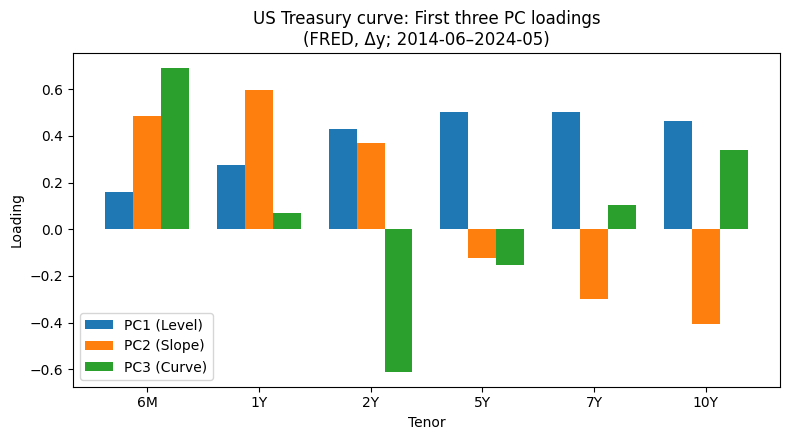

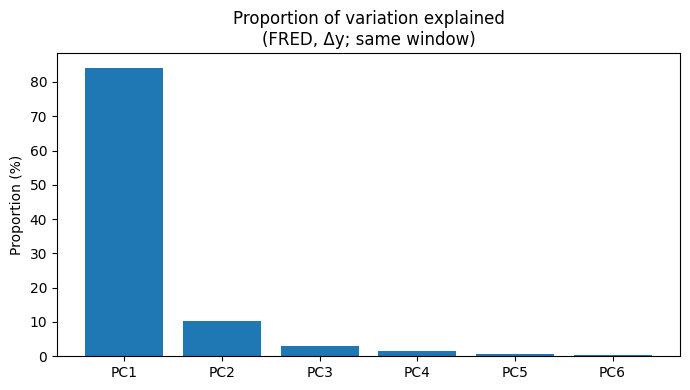

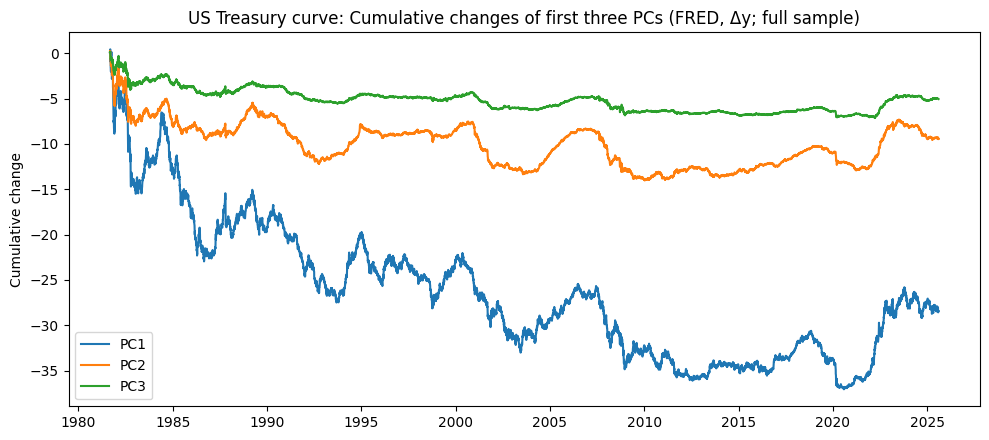

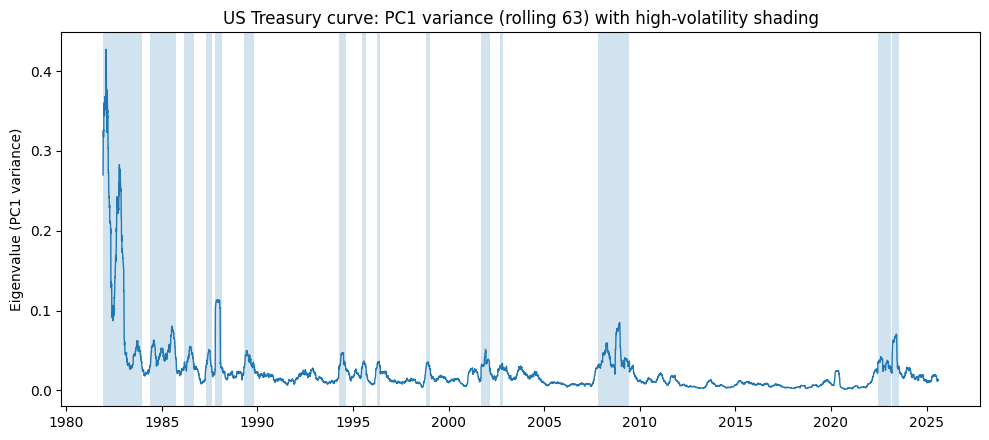

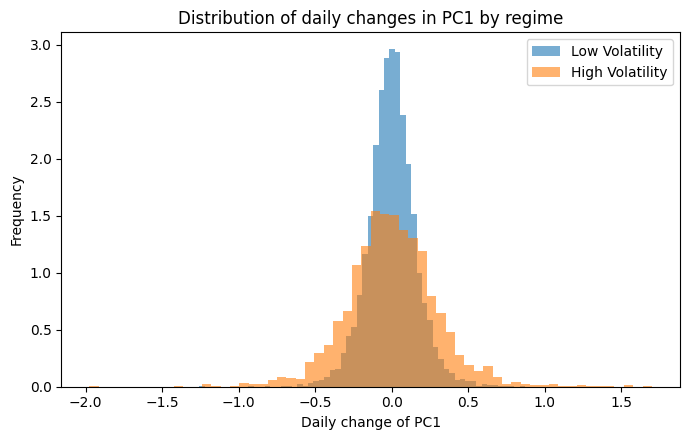

# 기간 다르게 ( 1986~2024 )

               6M     1Y     2Y     3Y     5Y     7Y    10Y
1981-09-01  17.17  17.06  16.78  16.57  16.12  15.71  15.41
1981-09-02  17.32  17.16  16.78  16.43  16.09  15.75  15.40
1981-09-03  17.42  17.31  16.90  16.48  16.14  15.78  15.48
1981-09-04  17.37  17.24  16.89  16.52  16.17  15.86  15.51
1981-09-07    NaN    NaN    NaN    NaN    NaN    NaN    NaN


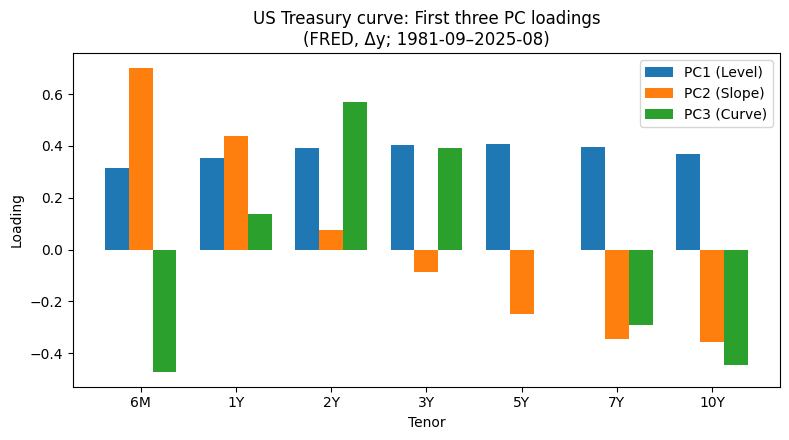

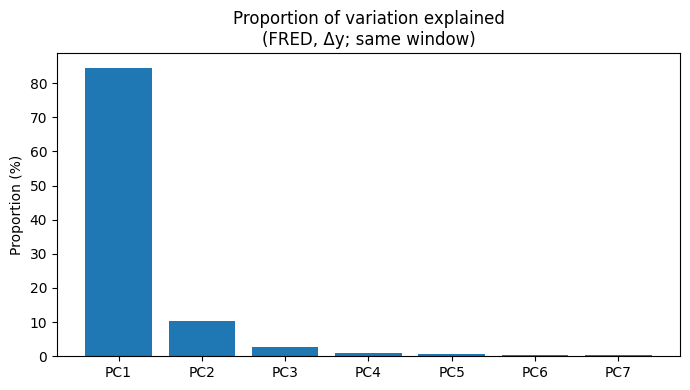

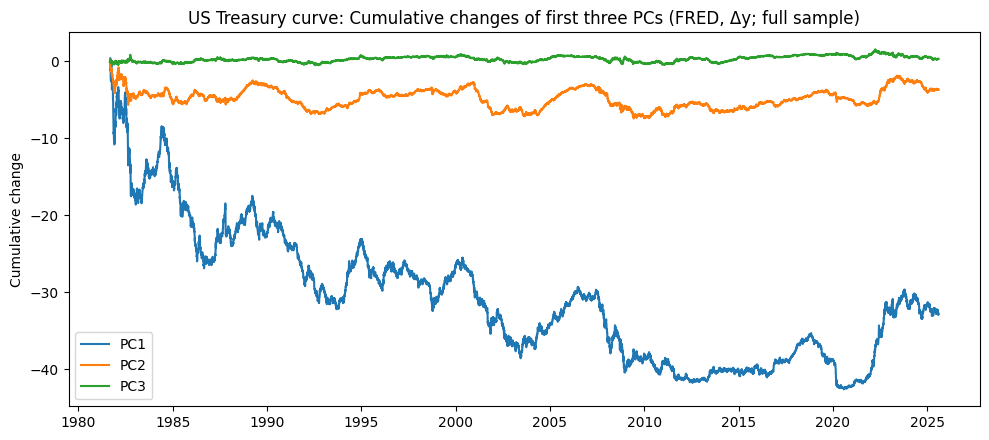

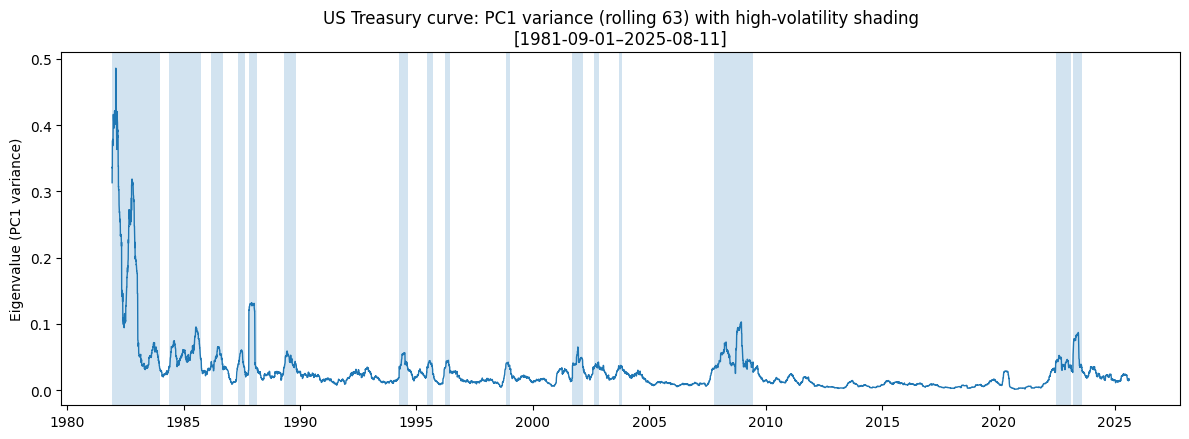

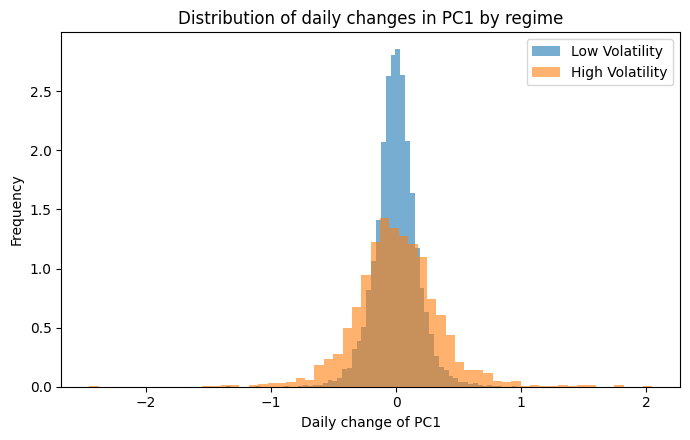

In [4]:
# ================================
# PCA-HMM (FRED 버전, 1996–2024 전용)
# Targets: Fig.1, Fig.2, Fig.4, Fig.8, Fig.9
# Requirements:
#   - fredapi (pip install fredapi)
#   - hmmlearn (pip install hmmlearn)
#   - scikit-learn, matplotlib, pandas, numpy
# Notes:
#   - Δ수익률(퍼센트포인트)로 PCA 수행 (표준화 X)
#   - 롤링 63영업일(≈3개월)로 PC1 분산 추출 → 2상태 HMM
# ================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred

# ---------- 0) 설정 ----------
FRED_API_KEY = "b660f214252bd9779c7a5b1c570bb13e"  
START_DATE   = "1981-09-01"
END_DATE     = "2025-08-11"
ROLL_WIN     = 63  # ≈ 3개월 영업일
FIG12_START  = START_DATE
FIG12_END    = END_DATE

# 표준 테너 순서(있는 것만 사용)
TENOR_ORDER = ["6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

# ---------- 1) FRED 데이터 수집 ----------
fred_tickers = {
    # T-Bill/단기물
    "DGS6MO": "6M",
    # 수익률곡선 주요 만기
    "DGS1": "1Y",
    "DGS2": "2Y",
    "DGS3": "3Y",
    "DGS5": "5Y",
    "DGS7": "7Y",
    "DGS10": "10Y",
}

fred = Fred(api_key=FRED_API_KEY)

df_fred_yields = pd.DataFrame()
for code, label in fred_tickers.items():
    s = fred.get_series(code)
    df_fred_yields[label] = s
print(df_fred_yields.head())
# 인덱스 정리 및 기간 슬라이스
df_fred_yields.index = pd.to_datetime(df_fred_yields.index)
df_fred_yields = df_fred_yields.loc[START_DATE:END_DATE].dropna(how="any")

# Δ수익률(퍼센트포인트 차분)
df_fred_returns = df_fred_yields.diff().dropna()

# 분석에 쓸 컬럼 정렬(실제 존재하는 것만)
cols_sorted = [c for c in TENOR_ORDER if c in df_fred_returns.columns]
if not cols_sorted:
    cols_sorted = list(df_fred_returns.columns)

# ---------- 2) 유틸: 롤링 PCA + HMM ----------
def run_pca_hmm(returns_df: pd.DataFrame, window: int = 63, random_state: int = 42):
    """
    returns_df : (T x N) Δy 데이터프레임, 인덱스는 DatetimeIndex
    window     : 롤링 창(행 개수)
    반환       : (pc1_var_array, states_array)
                - pc1_var_array: 길이 T-window 의 1차원 배열 (각 창의 PC1 분산)
                - states_array : 길이 T-window 의 정수 상태(0/1)
    """
    X = returns_df.values
    T, N = X.shape
    if T <= window:
        raise ValueError("데이터 길이가 롤링 창보다 짧습니다.")

    # 2-1) 롤링 창마다 PCA → PC1 고유값(분산)
    pc1_vars = []
    for t in range(window, T):
        Xw = X[t - window:t, :]                # (window x N)
        pca = PCA()
        pca.fit(Xw)                            # 공분산 기반(표준화 X)
        ev1 = pca.explained_variance_[0]       # PC1 분산(고유값)
        pc1_vars.append(ev1)

    pc1_vars = np.asarray(pc1_vars)[:, None]   # (T-window, 1)

    # 2-2) 2상태 Gaussian HMM 적합 (PC1 분산 시계열)
    hmm = GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=300,
        random_state=random_state,
    )
    hmm.fit(pc1_vars)
    states = hmm.predict(pc1_vars)             # (T-window,)

    return pc1_vars.ravel(), states

# ---------- 3) Fig.1 & Fig.2: 고정 윈도우 PCA (Δy 공분산 기반) ----------
ret_win = df_fred_returns[cols_sorted].loc[FIG12_START:FIG12_END].dropna(how="any")
pca_fixed = PCA()
pca_fixed.fit(ret_win)

# 로딩(components_.T) 및 부호 안정화
L = pca_fixed.components_.T.copy()  # (N x K)
for k in range(min(3, L.shape[1])):  # PC1~PC3만 부호 고정
    col = L[:, k]
    if np.abs(col).max() > 0 and col[np.argmax(np.abs(col))] < 0:
        L[:, k] = -col

# Fig.1: 로딩 막대
plt.figure(figsize=(8, 4.5))
x = np.arange(len(cols_sorted))
w = 0.25
if L.shape[1] >= 1: plt.bar(x - w, L[:, 0], w, label="PC1 (Level)")
if L.shape[1] >= 2: plt.bar(x     , L[:, 1], w, label="PC2 (Slope)")
if L.shape[1] >= 3: plt.bar(x + w , L[:, 2], w, label="PC3 (Curve)")
plt.xticks(x, cols_sorted)
plt.ylabel("Loading")
plt.xlabel("Tenor")
plt.title(f"US Treasury curve: First three PC loadings\n(FRED, Δy; {pd.to_datetime(FIG12_START):%Y-%m}–{pd.to_datetime(FIG12_END):%Y-%m})")
plt.legend()
plt.tight_layout()
plt.show()

# Fig.2: 분산 기여율
ratio = pca_fixed.explained_variance_ratio_
plt.figure(figsize=(7, 4))
plt.bar([f"PC{i+1}" for i in range(len(ratio))], ratio * 100)
plt.ylabel("Proportion (%)")
plt.title("Proportion of variation explained\n(FRED, Δy; same window)")
plt.tight_layout()
plt.show()

# ---------- 4) Fig.4: 전체 구간에서 PC1~PC3 누적 변화 ----------
ret_all = df_fred_returns[cols_sorted].dropna(how="any")
scores = ret_all.values @ L[:, :min(3, L.shape[1])]
pc_cum = pd.DataFrame(
    scores, index=ret_all.index, columns=[f"PC{i+1}" for i in range(scores.shape[1])]
).cumsum()

plt.figure(figsize=(10, 4.5))
for c in pc_cum.columns:
    plt.plot(pc_cum.index, pc_cum[c], label=c)
plt.ylabel("Cumulative change")
plt.title("US Treasury curve: Cumulative changes of first three PCs (FRED, Δy; full sample)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 5) Fig.8: 롤링 PC1 고유값(분산) + 2상태 HMM 쉐이딩 ----------
pc1_var, states = run_pca_hmm(df_fred_returns[cols_sorted], window=ROLL_WIN)
# ROLL_WIN 이후부터 인덱스 매칭
ev_index = ret_all.index[ROLL_WIN:]
ev = pd.Series(pc1_var, index=ev_index)

# 어떤 상태가 high-vol인지 판별(평균 EV가 큰 상태)
state_means = pd.Series([ev.values[states == k].mean() for k in np.unique(states)])
high_state = int(state_means.idxmax())
is_high = (states == high_state)

plt.figure(figsize=(12, 4.5))
plt.plot(ev.index, ev.values, lw=1.0)
# 연속 high-vol 구간 음영
start = None
for t, flag in enumerate(is_high):
    if flag and start is None:
        start = ev.index[t]
    if (not flag or t == len(is_high) - 1) and start is not None:
        end = ev.index[t]
        plt.axvspan(start, end, alpha=0.2)
        start = None
plt.ylabel("Eigenvalue (PC1 variance)")
plt.title(f"US Treasury curve: PC1 variance (rolling {ROLL_WIN}) with high-volatility shading\n[{START_DATE}–{END_DATE}]")
plt.tight_layout()
plt.show()

# ---------- 6) Fig.9: 레짐별 PC1 일간 변화 히스토그램 ----------
# 고정 로딩(L)을 사용해 PC1 스코어 시계열 구성
pc1_series = pd.Series((ret_all.values @ L[:, 0]).ravel(), index=ret_all.index)
# 롤링 EV 인덱스와 정렬
pc1_align = pc1_series.loc[ev.index]
pc1_changes = pc1_align.diff().dropna()

# diff로 하루 줄어든 만큼 상태도 정렬
state_for_diff = is_high[1:]

plt.figure(figsize=(7, 4.5))
plt.hist(pc1_changes[~state_for_diff], bins=60, density=True, alpha=0.6, label="Low Volatility")
plt.hist(pc1_changes[state_for_diff],  bins=60, density=True, alpha=0.6, label="High Volatility")
plt.xlabel("Daily change of PC1")
plt.ylabel("Frequency")
plt.title("Distribution of daily changes in PC1 by regime")
plt.legend()
plt.tight_layout()
plt.show()


# 평가 

In [6]:

# 1) Level-HMM
# ======================
level_series = df_fred_yields["10Y"].dropna().values.reshape(-1, 1)
hmm_level = GaussianHMM(n_components=2, covariance_type="full", n_iter=300, random_state=42)
hmm_level.fit(level_series)
states_level = hmm_level.predict(level_series)

# high/low 판별
level_means = [level_series[states_level == k].mean() for k in range(2)]
high_state_level = np.argmax(level_means)
is_high_level = (states_level == high_state_level)

# ======================
# 2) Slope-HMM (10Y - 2Y)
# ======================
slope_series = (df_fred_yields["10Y"] - df_fred_yields["2Y"]).dropna().values.reshape(-1, 1)
hmm_slope = GaussianHMM(n_components=2, covariance_type="full", n_iter=300, random_state=42)
hmm_slope.fit(slope_series)
states_slope = hmm_slope.predict(slope_series)

slope_means = [slope_series[states_slope == k].mean() for k in range(2)]
high_state_slope = np.argmax(slope_means)
is_high_slope = (states_slope == high_state_slope)

# ======================
# 3) PCA-HMM (기존 결과)
# ======================
# 기존 코드에서 얻은 is_high 변수를 그대로 사용

# ======================
# 4) 비교: 상태 시계열 상관관계
# ======================
from scipy.stats import pearsonr

# 길이 맞추기 (공통 기간)
common_index = df_fred_yields.index.intersection(ev.index)  # ev.index는 PCA-HMM 기간
pca_states_common = is_high[ev.index.isin(common_index)].astype(int)
level_states_common = is_high_level[df_fred_yields.index.isin(common_index)].astype(int)
slope_states_common = is_high_slope[df_fred_yields.index.isin(common_index)].astype(int)

corr_pca_level = pearsonr(pca_states_common, level_states_common)[0]
corr_pca_slope = pearsonr(pca_states_common, slope_states_common)[0]

print(f"PCA-HMM vs Level-HMM correlation: {corr_pca_level:.3f}")
print(f"PCA-HMM vs Slope-HMM correlation: {corr_pca_slope:.3f}")

# ======================
# 5) 투자 성과 비교 (예: 10Y 채권 수익률 사용)
# ======================
bond_ret = df_fred_returns["10Y"].loc[common_index]  # Δyield로 간단 비교 예시

def regime_mean_return(ret_series, states_bool):
    return {
        "Low Regime Mean": ret_series[~states_bool].mean(),
        "High Regime Mean": ret_series[states_bool].mean()
    }

print("PCA-HMM:", regime_mean_return(bond_ret, pca_states_common))
print("Level-HMM:", regime_mean_return(bond_ret, level_states_common))
print("Slope-HMM:", regime_mean_return(bond_ret, slope_states_common))

PCA-HMM vs Level-HMM correlation: 0.213
PCA-HMM vs Slope-HMM correlation: -0.006
PCA-HMM: {'Low Regime Mean': 0.008889295852028014, 'High Regime Mean': 0.2722186612947529}
Level-HMM: {'Low Regime Mean': 0.016786008607270038, 'High Regime Mean': 0.20312242468638383}
Slope-HMM: {'Low Regime Mean': 0.01911912828495518, 'High Regime Mean': 0.1827076275066384}


# MAcro Factor

In [ ]:
# 이건 pass ( 거시경제 변수 딴거 )

# ==========================================
# (추가) 거시변수 결합 HMM: 그래프 비교 패키지
#  - 기존 코드(금리 PCA/HMM)는 그대로 사용
#  - 아래 블록을 기존 코드 "Fig.9" 이후에 붙여 실행
#  - 필요 라이브러리: fredapi, hmmlearn, sklearn, matplotlib, pandas, numpy
# ==========================================
import pandas as pd
import numpy as np
from fredapi import Fred
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

START_DATE = "1981-09-01"
# ------- 0) 거시 변수 수집 (FRED: 월/주 자료 → 월말 → YoY/수준 → 일별 forward-fill) -------
# 사용할 변수:
# - 산업생산 YoY (INDPRO) 1919~
# - CPI YoY (CPIAUCSL) 1947~
# - 금융스트레스 (STLFSI4: 주간) → 월말로 다운샘플 STLFSI4도 1993년부터
# - 10Y Breakeven inflation (T10YIE) (수준 그대로)  2003년부터
# ※ 모두 무료, FRED 제공

fred = Fred(api_key=FRED_API_KEY)

def get_series(code):
    s = fred.get_series(code)
    s.index = pd.to_datetime(s.index)
    return s

s_indpro  = get_series("INDPRO")     # 월간지수
s_cpi     = get_series("CPIAUCSL")   # 월간지수
s_unemp  = get_series("UNRATE")      # 실업률(레벨, monthly)
s_m2     = get_series("M2SL")        # M2 (monthly, 선택)
#s_stlfsi4 = get_series("STLFSI4")    # 주간지수
#s_bke10y  = get_series("T10YIE")     # 일/영업일 수준(10y breakeven, %)

# 월말 샘플로 통일
m_indpro  = s_indpro.resample("M").last()
m_cpi     = s_cpi.resample("M").last()
#m_stl     = s_stlfsi4.resample("M").last()
#m_bke10y  = s_bke10y.resample("M").last()

# YoY 계산(지수형) – % 단위
m_indpro_yoy = m_indpro.pct_change(12) * 100
m_cpi_yoy    = m_cpi.pct_change(12) * 100

# 단위 정리: STLFSI4와 T10YIE는 수준 그대로 사용 (나중에 표준화)
macro_monthly = pd.concat(
    [m_indpro_yoy.rename("indpro_yoy"),
     m_cpi_yoy.rename("cpi_yoy"),
     #m_stl.rename("stlfsi"),
     #m_bke10y.rename("breakeven10y")],
     ],
    axis=1
).dropna(how="any")
macro_monthly = macro_monthly.loc[START_DATE:]

# 금리 Δy(일별) 인덱스에 forward-fill
daily_idx = df_fred_returns.index
macro_daily = macro_monthly.reindex(daily_idx, method="ffill").dropna(how="any")

# ------- 1) 금리 기반 롤링 PCA 고유값(PC1 variance) 시계열과 공통 구간 정렬 -------
# (기존 코드에서 이미 계산된 값 사용: ev = PC1 variance 시계열(ROLL_WIN 이후 인덱스))
# 공통 구간 맞추기
common_idx = ev.index.intersection(macro_daily.index)
ev_c  = ev.loc[common_idx].values.reshape(-1, 1)
mac_c = macro_daily.loc[common_idx]

# ------- 2) 표준화 후 다변량 HMM 입력 구성 -------
scaler = StandardScaler()
mac_z = scaler.fit_transform(mac_c.values)  # (T x K)
X_hmm_multi = np.column_stack([ev_c, mac_z])  # (T x (1+K))

# 금리 단일 특징(univariate)도 동일 구간으로 정렬 (비교용)
X_hmm_uni = ev_c.copy()

# ------- 3) HMM 적합 및 상태 라벨링 (어느 상태가 High-vol인지는 ev 평균으로 결정) -------
def fit_hmm_and_label_high(X, anchor_for_label):
    hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=500, random_state=42)
    hmm.fit(X)
    states = hmm.predict(X)
    # anchor_for_label: ev_c 또는 ev_c와 동일 길이의 PC1 variance 열(High 기준)
    means_by_state = [anchor_for_label[states==k].mean() for k in np.unique(states)]
    high_state = int(np.argmax(means_by_state))
    return states, high_state

states_uni, high_uni   = fit_hmm_and_label_high(X_hmm_uni, ev_c.ravel())
states_multi, high_multi = fit_hmm_and_label_high(X_hmm_multi, ev_c.ravel())

is_high_uni   = (states_uni   == high_uni)
is_high_multi = (states_multi == high_multi)

# ------- 4) 진단: 상태별 ev(PC1 분산) 평균/비율, High 비중(점유율) 출력 -------
def regime_stats(ev_vec, is_high_bool):
    low_mean  = float(np.mean(ev_vec[~is_high_bool]))
    high_mean = float(np.mean(ev_vec[ is_high_bool]))
    ratio     = high_mean / max(low_mean, 1e-12)
    share     = float(np.mean(is_high_bool))
    return {"low_mean": low_mean, "high_mean": high_mean, "ratio(H/L)": ratio, "high_share": share}

print("[UNIVARIATE HMM]  ", regime_stats(ev_c.ravel(), is_high_uni))
print("[MULTIVARIATE HMM]", regime_stats(ev_c.ravel(), is_high_multi))

# ==========================================
#   그래프: 기존 Fig.1/2/4은 이전 코드 그대로
#   아래는 Fig.8/9을 'uni vs multi' 비교로 확장
# ==========================================

# ------- Fig.8': PC1 variance (rolling) + 고변동성 음영 (uni vs multi) -------
plt.figure(figsize=(13, 4.6))
plt.plot(common_idx, ev_c.ravel(), lw=1.0, label="PC1 variance (rolling {})".format(ROLL_WIN))
import matplotlib.dates as mdates

# 음영 - UNIVARIATE (연한 파랑)
start = None
for t, flag in enumerate(is_high_uni):
    if flag and start is None:
        start = common_idx[t]
    if ((not flag) or t == len(is_high_uni)-1) and start is not None:
        end = common_idx[t]
        plt.axvspan(start, end, alpha=0.14, color='skyblue',
                    label="High-vol (uni)" if start == common_idx[0] else None)
        start = None

# 음영 - MULTIVARIATE (연한 주황)
start = None
for t, flag in enumerate(is_high_multi):
    if flag and start is None:
        start = common_idx[t]
    if ((not flag) or t == len(is_high_multi)-1) and start is not None:
        end = common_idx[t]
        plt.axvspan(start, end, alpha=0.22, color='orange',
                    label="High-vol (multi)" if start == common_idx[0] else None)
        start = None

plt.ylabel("Eigenvalue (PC1 variance)")
plt.title("US Treasury: PC1 variance (rolling {}) with regime shading\nUni (lighter) vs Multi (darker)".format(ROLL_WIN))
plt.legend()
# 📌 2년 단위로 x축 눈금 설정
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# ------- Fig.9': 레짐별 PC1 일간 변화 히스토그램 (uni vs multi) -------
# 기존 PC1 스코어(고정 로딩)에서 일간 변화 계산 (이미 ret_all & L 사용)
pc1_series_full = pd.Series((ret_all.values @ L[:, 0]).ravel(), index=ret_all.index)
pc1_align = pc1_series_full.loc[common_idx]        # 인덱스 맞춤
pc1_chg   = pc1_align.diff().dropna()

# 상태 불린도 한 칸 미뤄서 정렬
is_high_uni_for_diff   = is_high_uni[1:]
is_high_multi_for_diff = is_high_multi[1:]
idx_for_hist = pc1_chg.index  # common_idx[1:]

plt.figure(figsize=(7.4, 4.6))
plt.hist(pc1_chg[~is_high_uni_for_diff],   bins=60, density=True, alpha=0.45, label="Low (uni)")
plt.hist(pc1_chg[ is_high_uni_for_diff],   bins=60, density=True, alpha=0.45, label="High (uni)")
plt.hist(pc1_chg[~is_high_multi_for_diff], bins=60, density=True, alpha=0.45, label="Low (multi)")
plt.hist(pc1_chg[ is_high_multi_for_diff], bins=60, density=True, alpha=0.45, label="High (multi)")
plt.xlabel("Daily change of PC1")
plt.ylabel("Frequency")
plt.title("PC1 daily change by regime: Uni vs Multi")
plt.legend()
plt.tight_layout()
plt.show()

# ------- (선택) 보조 그래프: 거시 변수 추세 확인 -------
fig, ax = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
ax[0].plot(macro_daily.index, macro_daily["indpro_yoy"], lw=0.9); ax[0].set_ylabel("INDPRO YoY (%)")
ax[1].plot(macro_daily.index, macro_daily["cpi_yoy"], lw=0.9);    ax[1].set_ylabel("CPI YoY (%)")
#ax[2].plot(macro_daily.index, macro_daily["stlfsi"], lw=0.9);     ax[2].set_ylabel("STLFSI")
#ax[3].plot(macro_daily.index, macro_daily["breakeven10y"], lw=0.9); ax[3].set_ylabel("10Y BEI (%)")
ax[0].set_title("Macro features used in HMM (forward-filled to daily index)")
plt.tight_layout()
plt.show()


Model is not converging.  Current: -20205.498896905297 is not greater than -20205.49388718521. Delta is -0.005009720087400638


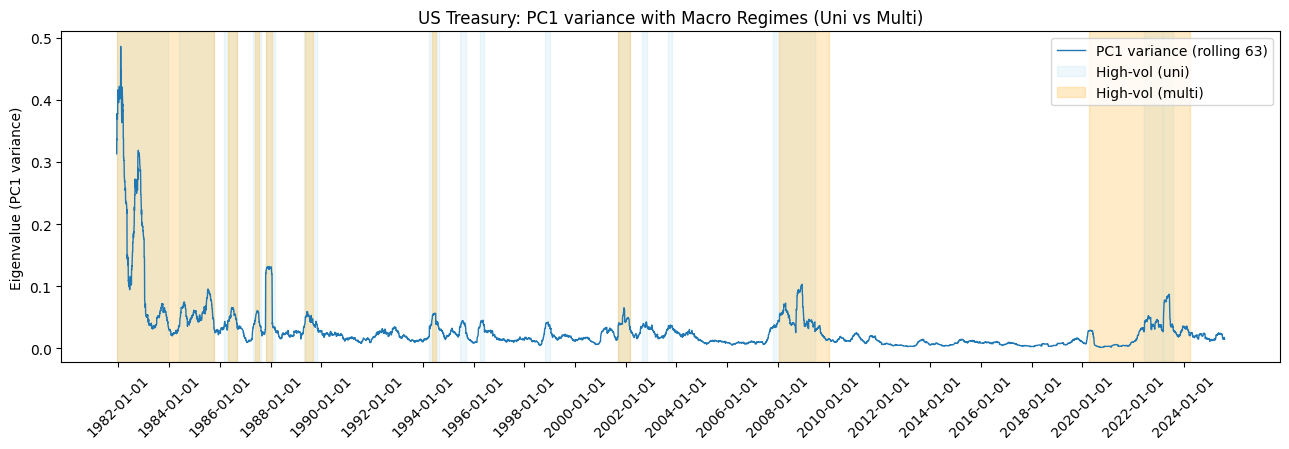

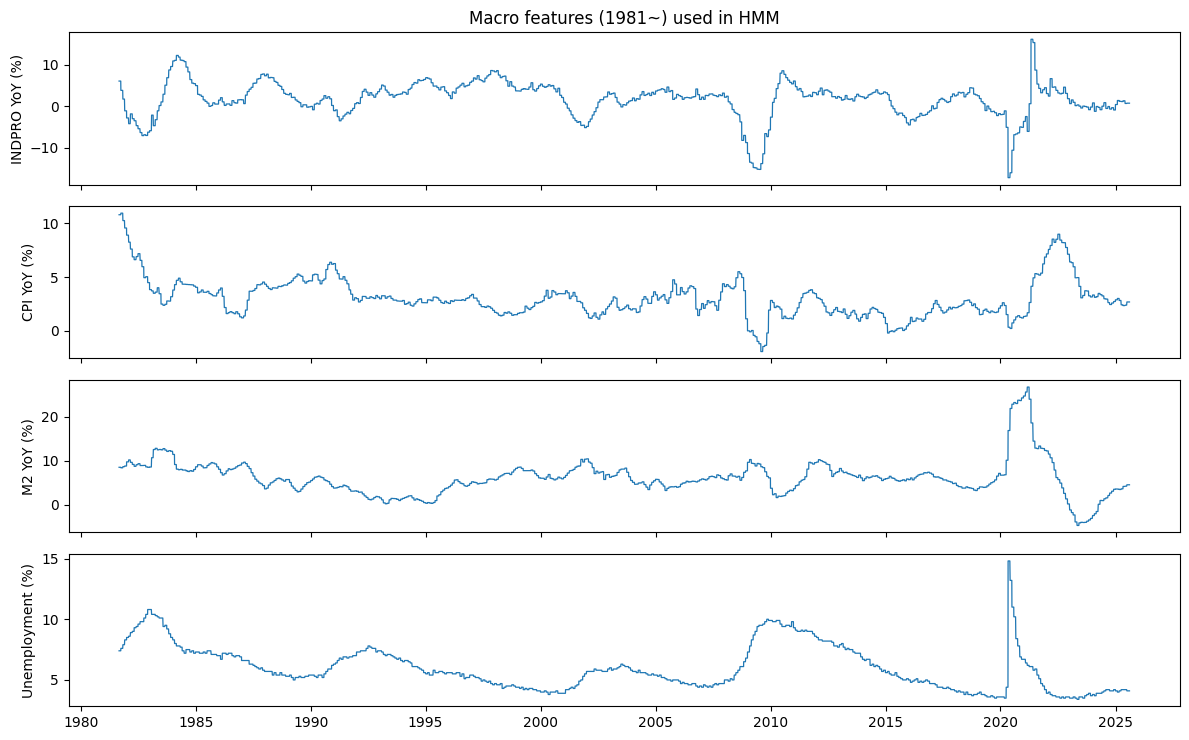

In [16]:
# ==========================================
# FRED 거시 변수 (1981~)
# ==========================================
import pandas as pd
import numpy as np
from fredapi import Fred
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

fred = Fred(api_key=FRED_API_KEY)

def get_series(code):
    s = fred.get_series(code)
    s.index = pd.to_datetime(s.index)
    return s

# -----------------------------
# 1) 거시 변수 불러오기
# -----------------------------
s_indpro  = get_series("INDPRO")     # 산업생산지수 (월간)
s_cpi     = get_series("CPIAUCSL")   # CPI (월간)
s_m2      = get_series("M2SL")       # M2 통화량 (월간)
s_unrate  = get_series("UNRATE")     # 실업률 (월간)

# 월말 기준으로 맞추기
m_indpro = s_indpro.resample("M").last()
m_cpi    = s_cpi.resample("M").last()
m_m2     = s_m2.resample("M").last()
m_unrate = s_unrate.resample("M").last()

# -----------------------------
# 2) YoY 변환 (실업률은 수준 그대로)
# -----------------------------
m_indpro_yoy = m_indpro.pct_change(12) * 100
m_cpi_yoy    = m_cpi.pct_change(12) * 100
m_m2_yoy     = m_m2.pct_change(12) * 100

# -----------------------------
# 3) 합치기
# -----------------------------
macro_monthly = pd.concat(
    [m_indpro_yoy.rename("indpro_yoy"),
     m_cpi_yoy.rename("cpi_yoy"),
     m_m2_yoy.rename("m2_yoy"),
     m_unrate.rename("unrate")],
    axis=1
).dropna(how="any")

# -----------------------------
# 4) 금리 Δy 인덱스에 forward-fill
# -----------------------------
daily_idx = df_fred_returns.index
macro_daily = macro_monthly.reindex(daily_idx, method="ffill").dropna(how="any")

# -----------------------------
# 5) 공통 구간 맞추기
# -----------------------------
common_idx = ev.index.intersection(macro_daily.index)
ev_c  = ev.loc[common_idx].values.reshape(-1, 1)
mac_c = macro_daily.loc[common_idx]

# -----------------------------
# 6) 표준화 및 HMM 입력
# -----------------------------
scaler = StandardScaler()
mac_z = scaler.fit_transform(mac_c.values)
X_hmm_multi = np.column_stack([ev_c, mac_z])
X_hmm_uni = ev_c.copy()

# -----------------------------
# 7) HMM 학습 함수
# -----------------------------
def fit_hmm_and_label_high(X, anchor_for_label):
    hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=500, random_state=42)
    hmm.fit(X)
    states = hmm.predict(X)
    means_by_state = [anchor_for_label[states==k].mean() for k in np.unique(states)]
    high_state = int(np.argmax(means_by_state))
    return states, high_state

states_uni, high_uni     = fit_hmm_and_label_high(X_hmm_uni, ev_c.ravel())
states_multi, high_multi = fit_hmm_and_label_high(X_hmm_multi, ev_c.ravel())

is_high_uni   = (states_uni == high_uni)
is_high_multi = (states_multi == high_multi)

# -----------------------------
# 8) 시각화 (기간축 2년 단위)
# -----------------------------
plt.figure(figsize=(13, 4.6))
plt.plot(common_idx, ev_c.ravel(), lw=1.0, label="PC1 variance (rolling {})".format(ROLL_WIN))

# UNIVARIATE 음영
start = None
for t, flag in enumerate(is_high_uni):
    if flag and start is None:
        start = common_idx[t]
    if ((not flag) or t == len(is_high_uni)-1) and start is not None:
        end = common_idx[t]
        plt.axvspan(start, end, alpha=0.14, color='skyblue',
                    label="High-vol (uni)" if start == common_idx[0] else None)
        start = None

# MULTIVARIATE 음영
start = None
for t, flag in enumerate(is_high_multi):
    if flag and start is None:
        start = common_idx[t]
    if ((not flag) or t == len(is_high_multi)-1) and start is not None:
        end = common_idx[t]
        plt.axvspan(start, end, alpha=0.22, color='orange',
                    label="High-vol (multi)" if start == common_idx[0] else None)
        start = None

plt.ylabel("Eigenvalue (PC1 variance)")
plt.title("US Treasury: PC1 variance with Macro Regimes (Uni vs Multi)")
plt.legend()
plt.xticks(pd.date_range(common_idx.min(), common_idx.max(), freq="2YS"), rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 9) 거시변수 확인
# -----------------------------
fig, ax = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
ax[0].plot(macro_daily.index, macro_daily["indpro_yoy"], lw=0.9); ax[0].set_ylabel("INDPRO YoY (%)")
ax[1].plot(macro_daily.index, macro_daily["cpi_yoy"], lw=0.9);    ax[1].set_ylabel("CPI YoY (%)")
ax[2].plot(macro_daily.index, macro_daily["m2_yoy"], lw=0.9);     ax[2].set_ylabel("M2 YoY (%)")
ax[3].plot(macro_daily.index, macro_daily["unrate"], lw=0.9);     ax[3].set_ylabel("Unemployment (%)")
ax[0].set_title("Macro features (1981~) used in HMM")
plt.tight_layout()
plt.show()
